In [1]:
# =============================================================================
# UNSW-NB15 DATASET: CYBERSECURITY ANALYTICS
# =============================================================================
# Models: Logistic Regression (ML) & Random Forest (ML)
# 1. Dataset Concatenation (Train + Test)
# 2. 10 Strategic & Highly Visual EDA Plots
# 3. Manual Random Oversampling for Class Balance
# 4. Comparative Evaluation & Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings

# --- Global Style Configurations ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# -----------------------------------------------------------------------------
# STEP 1: DATA CONCATENATION & CLEANING
# -----------------------------------------------------------------------------
try:
    # Load both files
    train_df = pd.read_csv('UNSW_NB15_training-set.csv')
    test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

    # Concatenate into one single dataset
    df = pd.concat([train_df, test_df], ignore_index=True)

    # Drop unique ID if present
    if 'id' in df.columns:
        df.drop('id', axis=1, inplace=True)

    print(f"✓ Dataset Unified. Total Rows: {df.shape[0]}, Total Features: {df.shape[1]}")
except Exception as e:
    print(f"Error loading files: {e}")

✓ Dataset Unified. Total Rows: 257673, Total Features: 44


In [3]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,1,3,0,0,0,2,3,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,1,3,0,0,0,2,3,0,Normal,0


In [4]:
df.tail()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
257668,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,13,24,0,0,0,24,24,0,Generic,1
257669,0.505762,tcp,-,FIN,10,8,620,354,33.612649,254,...,1,2,0,0,0,1,1,0,Shellcode,1
257670,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,13,0,0,0,3,12,0,Generic,1
257671,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,14,30,0,0,0,30,30,0,Generic,1
257672,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,16,30,0,0,0,30,30,0,Generic,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  di

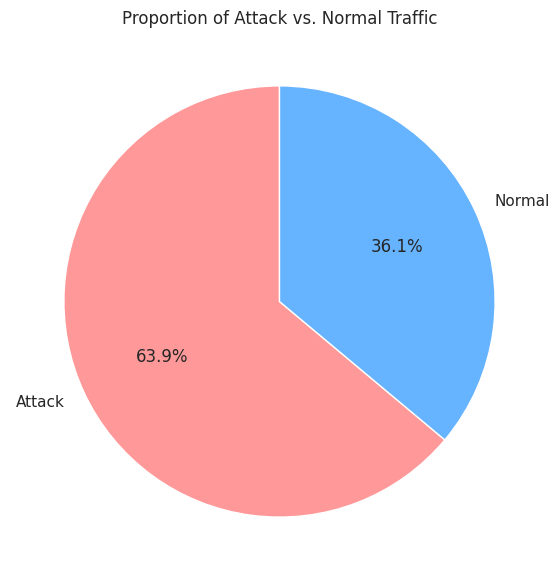

In [6]:
# 1. Pie Chart: Overall Network Traffic Split
plt.figure(figsize=(7,7))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Attack', 'Normal'], colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Proportion of Attack vs. Normal Traffic')
plt.ylabel('')
plt.show()

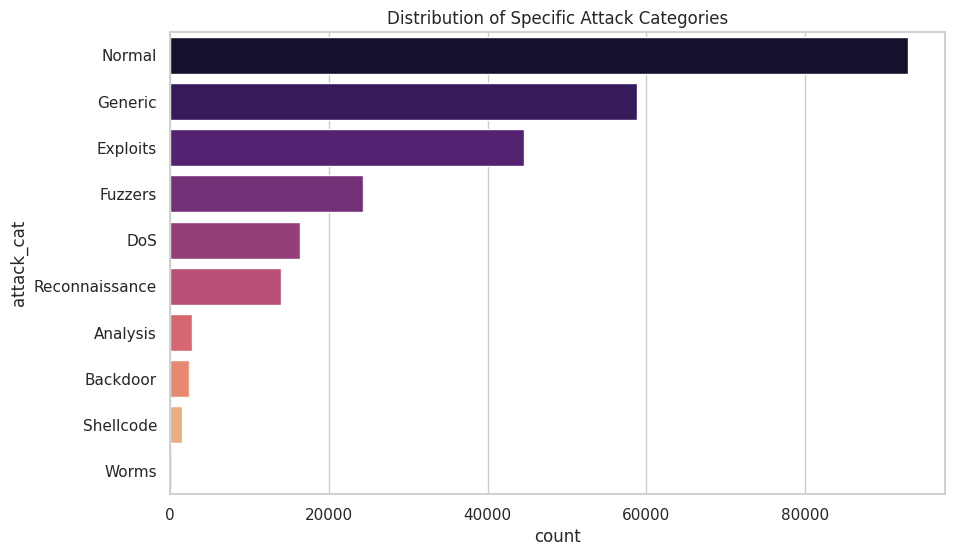

In [7]:
plt.figure()
sns.countplot(y='attack_cat', data=df, order=df['attack_cat'].value_counts().index, palette='magma')
plt.title('Distribution of Specific Attack Categories')
plt.show()

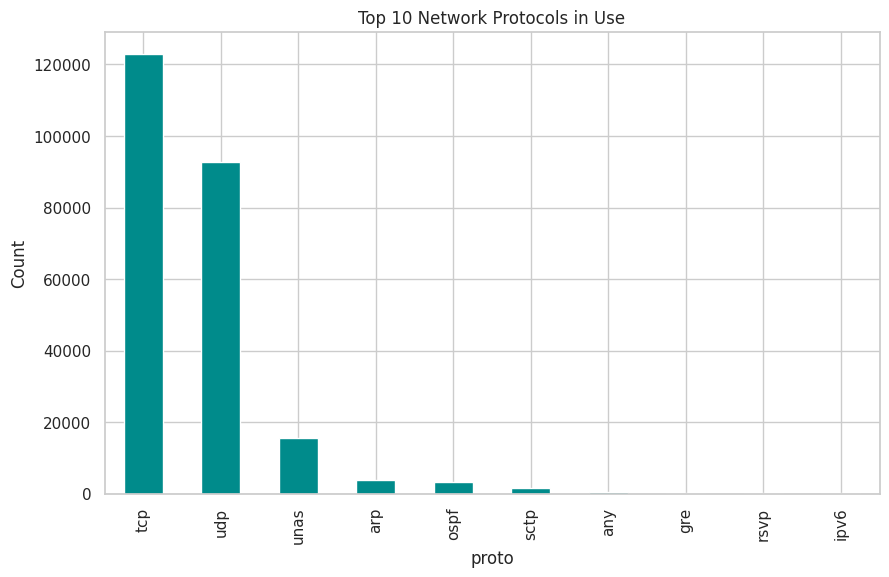

In [8]:
plt.figure()
df['proto'].value_counts().head(10).plot(kind='bar', color='darkcyan')
plt.title('Top 10 Network Protocols in Use')
plt.ylabel('Count')
plt.show()

<Figure size 1000x600 with 0 Axes>

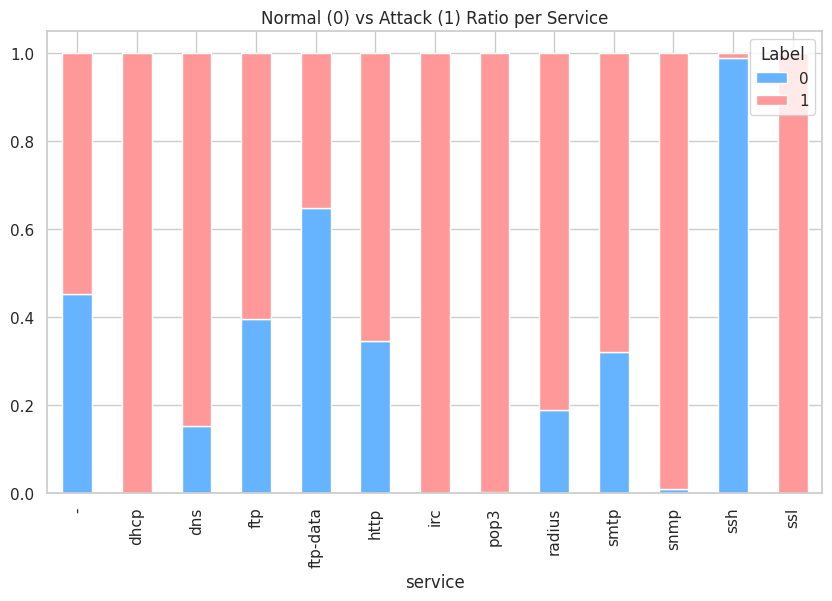

In [9]:
plt.figure()
service_pivot = pd.crosstab(df['service'], df['label'], normalize='index')
service_pivot.plot(kind='bar', stacked=True, color=['#66b3ff', '#ff9999'])
plt.title('Normal (0) vs Attack (1) Ratio per Service')
plt.legend(title='Label', loc='upper right')
plt.show()

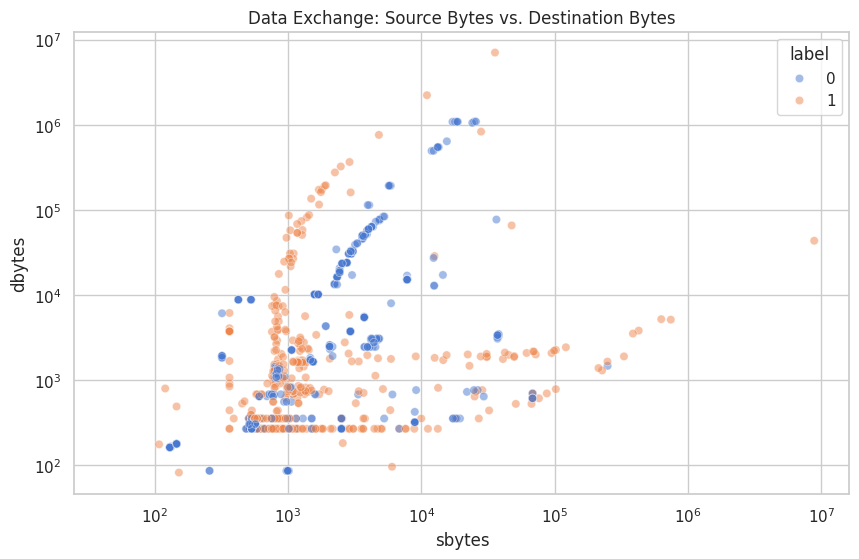

In [11]:
plt.figure()
sns.scatterplot(x='sbytes', y='dbytes', hue='label', data=df.sample(2000), alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.title('Data Exchange: Source Bytes vs. Destination Bytes')
plt.show()

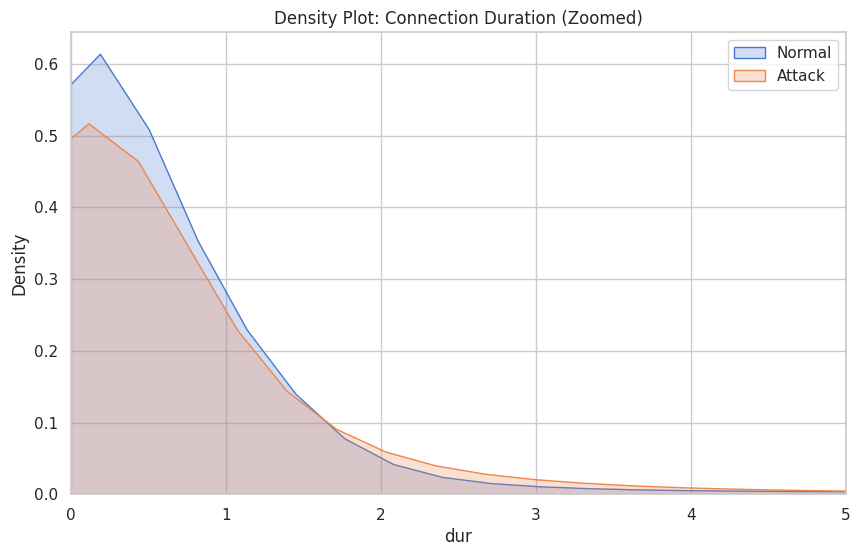

In [12]:
plt.figure()
sns.kdeplot(df[df['label']==0]['dur'], label='Normal', shade=True)
sns.kdeplot(df[df['label']==1]['dur'], label='Attack', shade=True)
plt.xlim(0, 5)
plt.title('Density Plot: Connection Duration (Zoomed)')
plt.legend()
plt.show()

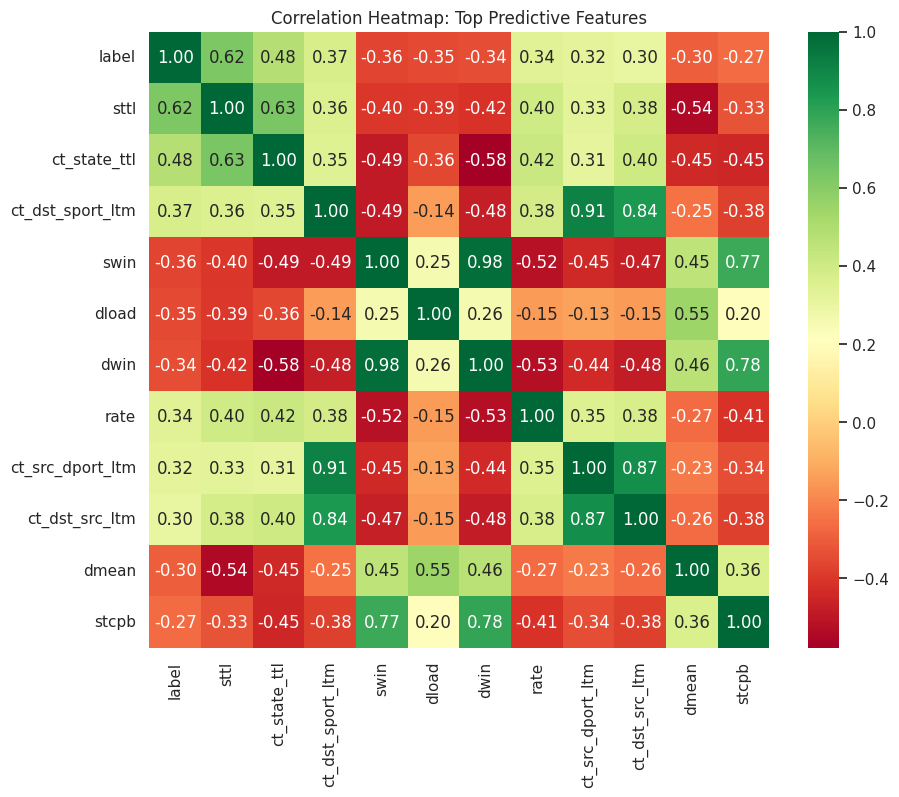

In [13]:
plt.figure(figsize=(10, 8))
top_corr = df.select_dtypes(include=[np.number]).corr()['label'].abs().sort_values(ascending=False).head(12).index
sns.heatmap(df[top_corr].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap: Top Predictive Features')
plt.show()

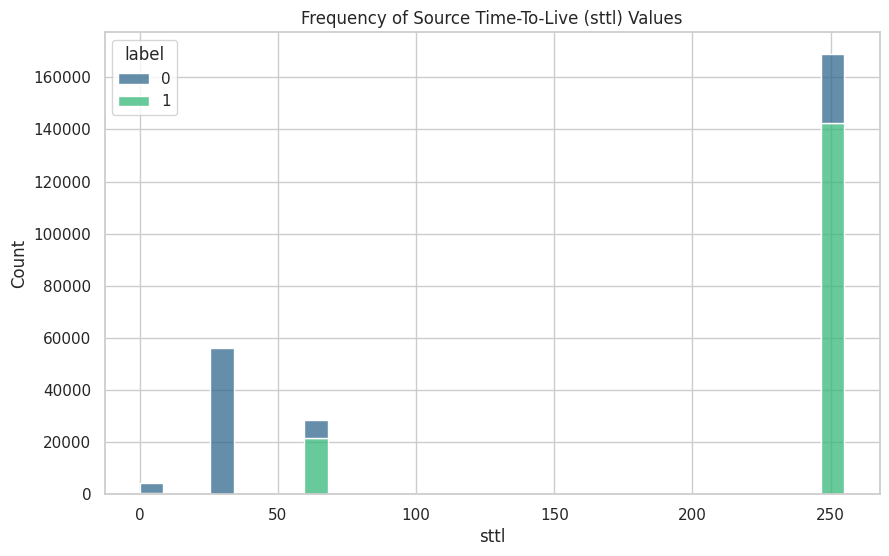

In [14]:
plt.figure()
sns.histplot(data=df, x='sttl', hue='label', bins=30, multiple='stack', palette='viridis')
plt.title('Frequency of Source Time-To-Live (sttl) Values')
plt.show()

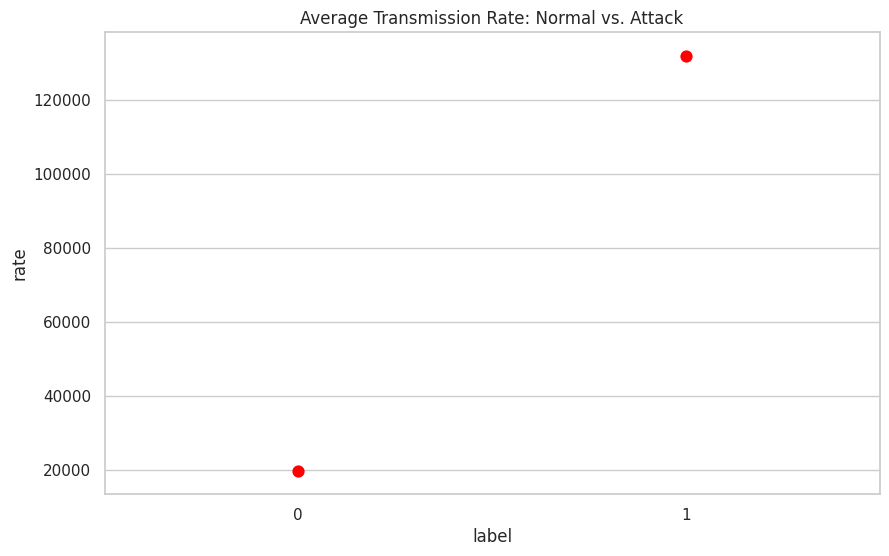

In [15]:
plt.figure()
sns.pointplot(x='label', y='rate', data=df, join=False, color='red')
plt.title('Average Transmission Rate: Normal vs. Attack')
plt.show()

In [16]:
# -----------------------------------------------------------------------------
# STEP 3: PRE-PROCESSING & MANUAL OVERSAMPLING
# -----------------------------------------------------------------------------
# Downsampling for environment efficiency
df_sample = df.sample(n=min(len(df), 50000), random_state=42)

# Encoding categorical columns
le = LabelEncoder()
for col in ['proto', 'service', 'state']:
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))

# Define X and y
X = df_sample.drop(['label', 'attack_cat'], axis=1)
y = df_sample['label']

# Split
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MANUAL RANDOM OVERSAMPLING ---
train_data = pd.concat([X_train_raw, y_train_raw], axis=1)
df_maj = train_data[train_data.label == 1]
df_min = train_data[train_data.label == 0]

# Upsample minority to match majority
df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_balanced = pd.concat([df_maj, df_min_upsampled])

X_train = train_balanced.drop('label', axis=1)
y_train = train_balanced['label']

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (ML ONLY)
# -----------------------------------------------------------------------------
results = []

# --- Model 1: Logistic Regression ---
print("\nTraining Logistic Regression...")
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

results.append({
    "Algorithm": "Logistic Regression",
    "Accuracy": round(accuracy_score(y_test, lr_preds), 4),
    "Precision": round(precision_score(y_test, lr_preds), 4),
    "Recall": round(recall_score(y_test, lr_preds), 4),
    "F1-Score": round(f1_score(y_test, lr_preds), 4)
})

# --- Model 2: Random Forest ---
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

results.append({
    "Algorithm": "Random Forest",
    "Accuracy": round(accuracy_score(y_test, rf_preds), 4),
    "Precision": round(precision_score(y_test, rf_preds), 4),
    "Recall": round(recall_score(y_test, rf_preds), 4),
    "F1-Score": round(f1_score(y_test, rf_preds), 4)
})


Training Logistic Regression...
Training Random Forest...


In [18]:
# -----------------------------------------------------------------------------
# STEP 5: FINAL PERFORMANCE RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*70)
print("STUDENT 2: MACHINE LEARNING PERFORMANCE RANK TABLE")
print("="*70)
print(rank_table)


STUDENT 2: MACHINE LEARNING PERFORMANCE RANK TABLE
                Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                            
1           Random Forest    0.9361     0.9638  0.9349    0.9491
2     Logistic Regression    0.8953     0.9255  0.9088    0.9171


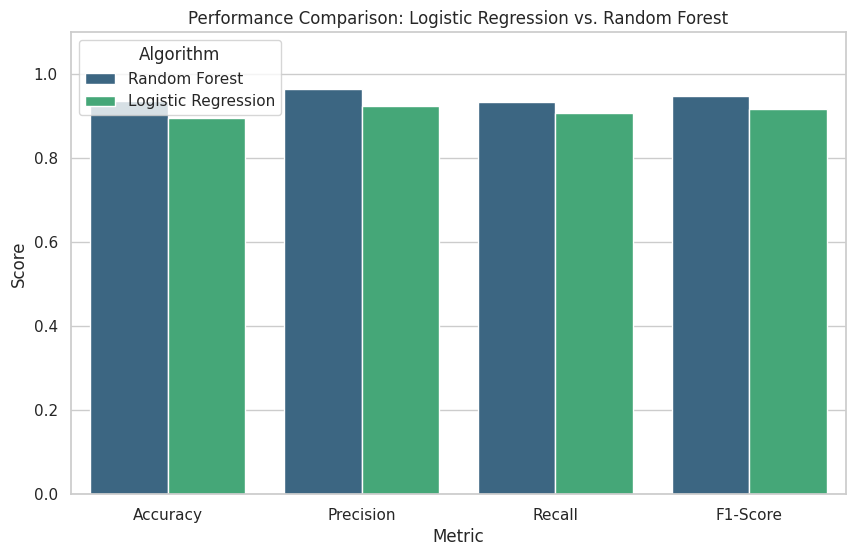

In [19]:
# Visual Comparison of Metrics
plt.figure()
melted = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=melted, palette='viridis')
plt.title('Performance Comparison: Logistic Regression vs. Random Forest')
plt.ylim(0, 1.1)
plt.show()